In [147]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime
from IPython.display import clear_output
from matplotlib.widgets import Slider
from sktime.performance_metrics.forecasting import MeanSquaredError as MSEsktime
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_squared_error as mse
from matplotlib.widgets import Slider
from tensorflow.keras.models import Sequential
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.metrics import RootMeanSquaredError
from tensorflow.keras.layers import Dense, InputLayer, LSTM
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import load_model
import random

import os

Some global variables:

In [19]:
state = 'ME'
target = 'customers_out_max'
#features = ['event_count Flood','event_count Storm', 'event_count Hurricane', 'event_count Heat', 
#            'event_count Fire', 'event_count Wind', 'event_count Ocean', 'event_count Other', 
#            't2m', 'u10', 'v10', 'sf', 'tp', 'customers_out_state', 'customers_out']
features = ['event_count Flood','event_count Storm', 'event_count Hurricane', 'event_count Heat', 
            'event_count Fire', 'event_count Wind', 'event_count Ocean', 'event_count Other', 
            't2m', 'sf', 'tp', 't2m_mean', 't2m_max', 'sf_mean', 'sf_max', 'tp_mean',
            'tp_max', 'wind_speed', 'neighbor_max_wind_speed','customers_out_state', 'customers_out','customers_out_max']

In [20]:
#file_path = os.path.join('..','..', 'data', 'Merged_data', 'eaglei_noaa_era5_full.parquet')
file_path = os.path.join('..','..', 'data', 'Merged_data', 'eaglei_noaa_era5_engineered.parquet')
df = pd.read_parquet(file_path)

In [3]:
df.head()

,fips_code,customers_out,datetime,YEAR,NAME,STUSPS,Pct_Buried_Lines,neighbors,Subregion,centroid_longitude,...,sf_max,tp_mean,tp_max,wind_speed,neighbor_mean_wind_speed,neighbor_max_wind_speed,sf_12h,sf_24h,tp_12h,tp_24h
0,1001,0.0,2014-01-01 00:00:00,2014,Autauga,AL,0.079844,"[1051, 1085, 1101, 1047, 1021]",SRSO,-86.6,...,0.0,9.278619e-06,2.248105e-05,1.729728,1.575794,1.423069,NaN,NaN,NaN,NaN
1,1001,0.0,2014-01-01 06:00:00,2014,Autauga,AL,0.079844,"[1051, 1085, 1101, 1047, 1021]",SRSO,-86.6,...,0.0,0.000000e+00,0.000000e+00,1.505424,1.427650,1.428905,0.0,NaN,3.288352e-06,NaN
2,1001,0.0,2014-01-01 12:00:00,2014,Autauga,AL,0.079844,"[1051, 1085, 1101, 1047, 1021]",SRSO,-86.6,...,0.0,4.351138e-07,4.351138e-07,1.395026,1.296653,1.280978,0.0,NaN,4.351138e-07,NaN
3,1001,0.0,2014-01-01 18:00:00,2014,Autauga,AL,0.079844,"[1051, 1085, 1101, 1047, 1021]",SRSO,-86.6,...,0.0,3.120154e-05,8.401871e-05,1.360247,1.273009,1.809449,0.0,0.0,9.620190e-06,0.000013
4,1001,0.0,2014-01-02 00:00:00,2014,Autauga,AL,0.079844,"[1051, 1085, 1101, 1047, 1021]",SRSO,-86.6,...,0.0,1.970395e-04,4.072428e-04,1.749216,1.658894,1.713748,0.0,0.0,1.479983e-04,0.000148


In [21]:
df_state = df[(df['STUSPS']==state) & (df['datetime']<datetime.datetime(2021,1,1))]
del df
df_state

,fips_code,customers_out,datetime,YEAR,NAME,STUSPS,Pct_Buried_Lines,neighbors,Subregion,centroid_longitude,...,sf_max,tp_mean,tp_max,wind_speed,neighbor_mean_wind_speed,neighbor_max_wind_speed,sf_12h,sf_24h,tp_12h,tp_24h
1645420,23001,0.000000,2014-01-01 00:00:00,2014,Androscoggin,ME,0.067680,"[23017, 23023, 23007, 23005, 23011]",NEWE,-70.2,...,9.185076e-05,5.258735e-05,0.000094,0.900854,0.339447,1.468925,NaN,NaN,NaN,NaN
1645421,23001,0.000000,2014-01-01 06:00:00,2014,Androscoggin,ME,0.067680,"[23017, 23023, 23007, 23005, 23011]",NEWE,-70.2,...,2.569705e-04,9.667575e-05,0.000257,2.200923,2.357300,3.639969,0.000056,NaN,0.000059,NaN
1645422,23001,0.000000,2014-01-01 12:00:00,2014,Androscoggin,ME,0.067680,"[23017, 23023, 23007, 23005, 23011]",NEWE,-70.2,...,2.787374e-04,1.260877e-04,0.000281,1.831061,2.137628,2.893102,0.000049,NaN,0.000051,NaN
1645423,23001,0.000000,2014-01-01 18:00:00,2014,Androscoggin,ME,0.067680,"[23017, 23023, 23007, 23005, 23011]",NEWE,-70.2,...,3.290363e-04,1.691580e-04,0.000333,2.516264,3.296632,4.429329,0.000062,0.000118,0.000066,0.000125
1645424,23001,0.000000,2014-01-02 00:00:00,2014,Androscoggin,ME,0.067680,"[23017, 23023, 23007, 23005, 23011]",NEWE,-70.2,...,3.372803e-04,1.739651e-04,0.000343,2.045963,2.223886,2.671164,0.000076,0.000125,0.000083,0.000134
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28535007,23031,4.166667,2020-12-30 18:00:00,2020,York,ME,0.076586,"[23017, 33015, 33017, 33003, 23005]",NEWE,-70.7,...,1.490116e-07,8.851289e-07,0.000001,1.980479,1.563267,2.191290,0.000000,0.000002,0.000002,0.000005
28535008,23031,0.000000,2020-12-31 00:00:00,2020,York,ME,0.076586,"[23017, 33015, 33017, 33003, 23005]",NEWE,-70.7,...,1.430660e-04,5.148649e-05,0.000147,4.496807,3.522409,5.681473,0.000000,0.000000,0.000002,0.000003
28535009,23031,0.000000,2020-12-31 06:00:00,2020,York,ME,0.076586,"[23017, 33015, 33017, 33003, 23005]",NEWE,-70.7,...,1.334367e-03,9.256840e-04,0.001565,4.496161,3.297803,5.438880,0.000001,0.000001,0.000748,0.000750
28535010,23031,0.000000,2020-12-31 12:00:00,2020,York,ME,0.076586,"[23017, 33015, 33017, 33003, 23005]",NEWE,-70.7,...,2.652854e-03,2.714384e-03,0.003238,4.043089,3.332584,4.675266,0.000004,0.000004,0.003014,0.003016


In [22]:
df_state_agg = df_state.groupby('datetime', as_index=True)['customers_out'].sum()

df_state.drop('STUSPS',axis=1, inplace=True)
df_state.sort_values(by='datetime',inplace=True)

df_state['customers_out_max'] = df_state.groupby('fips_code')['customers_out'].rolling(4, min_periods=1).max().reset_index(level=0, drop=True)

df_state['customers_out_state'] = df_state['datetime'].map(df_state_agg)

In [23]:
df_state.describe().transpose()

,count,mean,min,25%,50%,75%,max,std
fips_code,163648.0,23016.0,23001.0,23008.5,23016.0,23023.5,23031.0,9.219573
customers_out,163648.0,94.792401,0.0,0.0,0.0,1.708333,99641.708333,1263.666693
datetime,163648,2017-07-02 09:00:00,2014-01-01 00:00:00,2015-10-02 04:30:00,2017-07-02 09:00:00,2019-04-02 13:30:00,2020-12-31 18:00:00,NaN
YEAR,163648.0,2017.000782,2014.0,2015.0,2017.0,2019.0,2020.0,2.000201
Pct_Buried_Lines,163648.0,0.057909,0.021048,0.051781,0.06768,0.06768,0.076586,0.015207
centroid_longitude,163648.0,-69.53125,-70.8,-70.25,-69.65,-68.975,-67.6,0.882272
centroid_latitude,163648.0,44.7,43.5,44.1,44.5,45.1,46.7,0.806228
POPULATION,163648.0,83022.5625,17535.0,35084.0,53323.0,111314.25,281674.0,70789.825031
BUILDVALUE,163648.0,10167083125.0,2550171000.0,4076317500.0,6247156000.0,11965936250.0,38329412000.0,9220443715.348085
AGRIVALUE,163648.0,36069312.5,0.0,9114000.0,23536500.0,42653500.0,201974000.0,48030119.124752


In [203]:
fips_list = df_state.fips_code.unique()

The cell below is to test with a smaller number of counties:

In [25]:
fips_list= random.sample(list(fips_list),2)
fips_list

[23011, 23015]

Since some counties are missing data for some timeframes, we save the min and max date for each fips in `fips_time_ranges`

In [202]:
fips_time_ranges = df_state.groupby('fips_code', as_index=True)['datetime'].agg(['min','max','count'])

## Training using LSTM

In [205]:
WINDOW_SIZE = 20

FORECAST_SIZE = 4

In [206]:
def data_to_input_and_output(data,target,features):
    """
    Inputs:
    data - a timeseries in dataframe format, should be longer than WINDOW_SIZE
    target - a string with the name of the target feature
    features - a list with the names of all features used for training, should contain 'target'

    Returns:
    input_data - whose entries will be WINDOW_SIZE consecutive entries of data
    output_data - whose entries will be the element that follows after the WINDOW_SIZE consecutive elements

    For example if data = [0,1,2,3,4,5] and WINDOW_SIZE = 2 then
    input_data      output_data
    [[0,1],         [2,
    [1,2],           3,
    [2,3],           4,
    [3,4]]           5]
    """

    input_data = []
    output_data = []

    for index in range(WINDOW_SIZE,len(data)-FORECAST_SIZE):
        input_sample = data[features].iloc[index-WINDOW_SIZE:index]
        output_sample = data[target].iloc[index:index+FORECAST_SIZE]

        input_data.append(input_sample)
        output_data.append(output_sample)
    
    return np.array(input_data), np.array(output_data)

In [207]:
def lstm_model(X, y, epochs = 10, learning_rate=0.005,units = 28,dropout= 0.2 ,validation_data = None):
    """
    Inputs:
    X - the input_data obtained from data_to_input_and_output
    y - the output_data obtained from data_to_input_and_output

    Returns:
    model - a LTSM neural network trained on X and y
    """
    feat_len = X.shape[2]

    model = Sequential()
    model.add(InputLayer((WINDOW_SIZE,feat_len)))
    model.add(LSTM(units,dropout=dropout))
    model.add(Dense(8,'relu'))
    model.add(Dense(FORECAST_SIZE,'linear'))

    #check_point = ModelCheckpoint('model/checkpoint.keras', save_best_only=True, monitor='loss')

    model.compile(loss=MeanSquaredError(), optimizer=Adam(learning_rate=learning_rate), metrics=[RootMeanSquaredError()])
    model.fit(X, y, epochs= epochs, verbose=1, validation_data=validation_data)

    return model

In [208]:
class RMMScaler:
    def __init__(self, feature_range=(0, 1),pwr = 2, copy=True, clip=False):
        self.feature_range = feature_range
        self.copy = copy
        self.clip = clip
        self.pwr = pwr
        self.scaler = MinMaxScaler(feature_range=self.feature_range, copy=self.copy, clip=self.clip)
    
    def fit(self,X,y=None):
        return self.scaler.fit(X)
    
    def transform(self,X):
        return np.power(self.scaler.transform(X),1/(self.pwr))
    def inverse_transform(self,X):
        return self.scaler.inverse_transform(np.power(X,self.pwr))

The code below scales everything, and scales back after predictions

In [102]:
tscv = TimeSeriesSplit()
partial_scaling = False

metrics = {fips: [] for fips in fips_list} # contains the metrics for the model on each split
time_indices = {fips: [] for fips in fips_list} # contains a tuple with the indices for each train and test split
train_results = {fips: [] for fips in fips_list}
test_results = {fips: [] for fips in fips_list}

for fips in fips_list:
    
    df_county = df_state[df_state['fips_code']==fips]
    start_t = fips_time_ranges.loc[fips]['min']
    end_t = fips_time_ranges.loc[fips]['max']
    
    for i, (train_index, test_index) in enumerate(tscv.split(df_county)):
        
        clear_output(wait=False)
        print(f'Split #{i+1} for fips: {int(fips)}')

        df_train = df_county.iloc[train_index]
        df_test = df_county.iloc[test_index]
        time_indices[fips].append([train_index,test_index])
        mm = RMMScaler(feature_range=(0,1), clip=True, pwr = 2)
        mm.fit(df_train[features])
        df_train_scaled = pd.DataFrame(mm.transform(df_train[features]),columns=features)
        df_test_scaled = pd.DataFrame(mm.transform(df_test[features]),columns=features)

        train_input, train_output = data_to_input_and_output(df_train_scaled,target,features)
        test_input, test_output = data_to_input_and_output(df_test_scaled,target,features)

        model = lstm_model(train_input, train_output,dropout=0.4,units=40,validation_data=(test_input,test_output))
        metrics[fips].append(model.get_metrics_result())

        train_pred_scaled = model.predict(train_input)
        test_pred_scaled = model.predict(test_input)

        fill = np.zeros_like(df_train[features[:-1]].iloc[WINDOW_SIZE:-FORECAST_SIZE].values)
        fillp = np.zeros_like(df_test[features[:-1]].iloc[WINDOW_SIZE:-FORECAST_SIZE].values)

        #predictions for the present
        Xtrain = np.hstack([fill,train_pred_scaled[:,[0]]])
        Xpred = np.hstack([fillp,test_pred_scaled[:,[0]]])

        #future forecast (6hrs * FORECAST_SIZE hours into the future)
        Xtrainf = np.hstack([fill,train_pred_scaled[:,[FORECAST_SIZE-1]]]) 
        Xpredf = np.hstack([fillp,test_pred_scaled[:,[FORECAST_SIZE-1]]])

        train_actual_result = pd.DataFrame({'Actual':df_train[target].values}, index = df_train['datetime'])
        train_pred_result = pd.DataFrame({'Predicted':mm.inverse_transform(Xtrain)[:,-1]},
                                            index = df_county['datetime'].iloc[train_index[WINDOW_SIZE:-FORECAST_SIZE]])
        train_forecast_result = pd.DataFrame({'Forecast':mm.inverse_transform(Xtrainf)[:,-1]},
                                            index = df_county['datetime'].iloc[train_index[WINDOW_SIZE+FORECAST_SIZE:]])
        train_results[fips].append(pd.concat([train_actual_result,train_pred_result,train_forecast_result], axis=1))

        test_actual_result = pd.DataFrame({'Actual':df_test[target].values}, index = df_test['datetime'])
        test_pred_result = pd.DataFrame({'Predicted':mm.inverse_transform(Xpred)[:,-1]},
                                            index = df_county['datetime'].iloc[test_index[WINDOW_SIZE:-FORECAST_SIZE]])
        test_forecast_result = pd.DataFrame({'Forecast':mm.inverse_transform(Xpredf)[:,-1]},
                                            index = df_county['datetime'].iloc[test_index[WINDOW_SIZE+FORECAST_SIZE:]])
        test_results[fips].append(pd.concat([test_actual_result,test_pred_result,test_forecast_result], axis=1))
    
    saved_path = f'model/LSTM_{state}_{fips}.keras'
    model.save(saved_path)

#Took 2 hours to train on 90 counties, can probably be optimized

Split #5 for fips: 23015
Epoch 1/10
266/266 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0055 - root_mean_squared_error: 0.0731 - val_loss: 0.0067 - val_root_mean_squared_error: 0.0819
Epoch 2/10
266/266 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0041 - root_mean_squared_error: 0.0639 - val_loss: 0.0043 - val_root_mean_squared_error: 0.0659
Epoch 3/10
266/266 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0023 - root_mean_squared_error: 0.0479 - val_loss: 0.0039 - val_root_mean_squared_error: 0.0627
Epoch 4/10
266/266 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0023 - root_mean_squared_error: 0.0481 - val_loss: 0.0040 - val_root_mean_squared_error: 0.0632
Epoch 5/10
266/266 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0029 - root_mean_squared_error: 0.0535 - val_loss: 0.0043 - val_root_mean_squared_error: 0.0655
Epoch 6/10
266/266 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0023 - root_mean_squared_error: 0.0473 - val_loss: 0.0042 - val_root_mean_squared_error: 0.0645
Epoch 7/10
266/266 ━━━━━━━━

The code below only scales the input, not the output. (Easier to read RMSE when training)

In [ ]:
tscv = TimeSeriesSplit()
partial_scaling = False

metrics = {fips: [] for fips in fips_list} # contains the metrics for the model on each split
time_indices = {fips: [] for fips in fips_list} # contains a tuple with the indices for each train and test split
train_results = {fips: [] for fips in fips_list}
test_results = {fips: [] for fips in fips_list}

for fips in fips_list:
    
    df_county = df_state[df_state['fips_code']==fips]
    start_t = fips_time_ranges.loc[fips]['min']
    end_t = fips_time_ranges.loc[fips]['max']
    
    for i, (train_index, test_index) in enumerate(tscv.split(df_county)):
        
        clear_output(wait=False)
        print(f'Split #{i+1} for fips: {int(fips)}')

        df_train = df_county.iloc[train_index]
        df_test = df_county.iloc[test_index]
        time_indices[fips].append([train_index,test_index])
        
        mm = RMMScaler(feature_range=(0,1), clip=True, pwr = 4)
        mm.fit(df_train[features])
        df_train_scaled = pd.DataFrame(mm.transform(df_train[features]),columns=features)
        df_test_scaled = pd.DataFrame(mm.transform(df_test[features]),columns=features)

        _ , train_output = data_to_input_and_output(df_train,target,features)
        _ , test_output = data_to_input_and_output(df_test,target,features)

        train_input_scaled , _ = data_to_input_and_output(df_train_scaled,target,features)
        test_input_scaled , _ = data_to_input_and_output(df_test_scaled,target,features)

        model = lstm_model(train_input_scaled, train_output,dropout=0.2,validation_data=(test_input,test_output))
        metrics[fips].append(model.get_metrics_result())

        train_pred = model.predict(train_input_scaled)
        test_pred = model.predict(test_input_scaled)

        train_actual_result = pd.DataFrame({'Actual':df_train[target].values}, index = df_train['datetime'])
        train_pred_result = pd.DataFrame({'Predicted':train_pred[:,0]},
                                            index = df_county['datetime'].iloc[train_index[WINDOW_SIZE:-FORECAST_SIZE]])
        train_forecast_result = pd.DataFrame({'Forecast':train_pred[:,-1]},
                                            index = df_county['datetime'].iloc[train_index[WINDOW_SIZE+FORECAST_SIZE:]])
        train_results[fips].append(pd.concat([train_actual_result,train_pred_result,train_forecast_result], axis=1))

        test_actual_result = pd.DataFrame({'Actual':df_test[target].values}, index = df_test['datetime'])
        test_pred_result = pd.DataFrame({'Predicted':test_pred[:,0]},
                                            index = df_county['datetime'].iloc[test_index[WINDOW_SIZE:-FORECAST_SIZE]])
        test_forecast_result = pd.DataFrame({'Forecast':test_pred[:,-1]},
                                            index = df_county['datetime'].iloc[test_index[WINDOW_SIZE+FORECAST_SIZE:]])
        test_results[fips].append(pd.concat([test_actual_result,test_pred_result,test_forecast_result], axis=1))
    
    saved_path = f'model/LSTM_{state}_{fips}.keras'
    model.save(saved_path)

#new_model = load_model('model/LTSM_ME_23011.keras')
#new_model.summary()
#Took 2 hours to train on 90 counties, can probably be optimized

Split #5 for fips: 23005
Epoch 1/10
266/266 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 12641072.0000 - root_mean_squared_error: 3512.7427 - val_loss: 12888665.0000 - val_root_mean_squared_error: 3590.0786
Epoch 2/10
266/266 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 10056222.0000 - root_mean_squared_error: 3098.8298 - val_loss: 12736567.0000 - val_root_mean_squared_error: 3568.8328
Epoch 3/10
266/266 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 10239030.0000 - root_mean_squared_error: 3147.5933 - val_loss: 12667430.0000 - val_root_mean_squared_error: 3559.1333
Epoch 4/10
266/266 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 8542451.0000 - root_mean_squared_error: 2872.0544 - val_loss: 12640994.0000 - val_root_mean_squared_error: 3555.4175
Epoch 5/10
266/266 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 10535091.0000 - root_mean_squared_error: 3166.1199 - val_loss: 12655993.0000 - val_root_mean_squared_error: 3557.5264
Epoch 6/10
266/266 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 10923677.0000 - root_mean_

In [210]:
model.summary()

Model: "sequential_150"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_150 (LSTM)                 │ (None, 28)             │         5,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_300 (Dense)               │ (None, 8)              │           232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_301 (Dense)               │ (None, 4)              │            36 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,942 (70.09 KB)

 Trainable params: 5,980 (23.36 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 11,962 (46.73 KB)

In [211]:
print('RMSE for each FIPS')
for fips in fips_list:
    print(f'{int(fips)}: {metrics[fips][-1]['root_mean_squared_error']}')

RMSE for each FIPS
23001: 2035.6976318359375
23007: 1466.346923828125
23009: 1177.64990234375
23011: 3157.06494140625
23013: 695.5239868164062
23003: 709.7756958007812
23015: 1095.4005126953125
23017: 1634.4288330078125
23019: 4141.5078125
23021: 983.2103881835938
23023: 854.5184936523438
23025: 1951.2332763671875
23027: 1648.904296875
23029: 431.0090026855469
23031: 2330.953369140625
23005: 3480.803466796875


## Predictions on training data

In [212]:
fips_test = random.choice(fips_list)
df_county = df_state[df_state['fips_code']==fips_test]

c:\Users\cacereje\AppData\Local\miniconda3\envs\erdos_spring_2025\Lib\site-packages\sktime\performance_metrics\forecasting\_classes.py:673: UserWarning: y_pred and y_true do not have the same column index. This may indicate incorrect objects passed to the metric. Indices of y_true will be used for y_pred.
  warn(


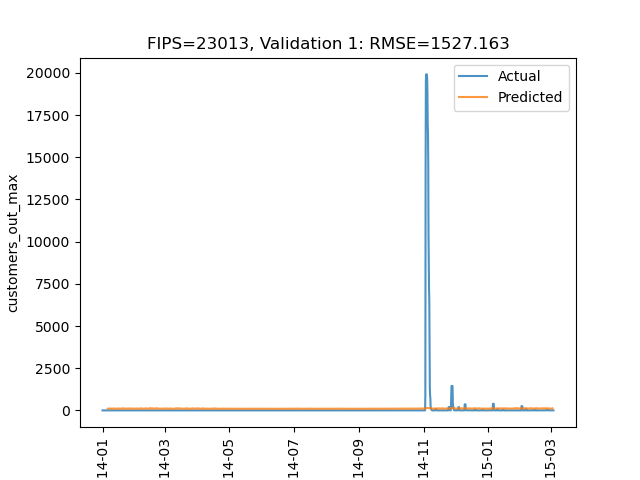

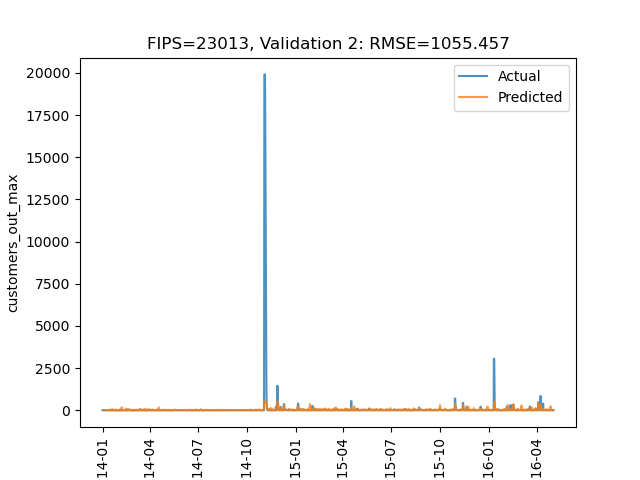

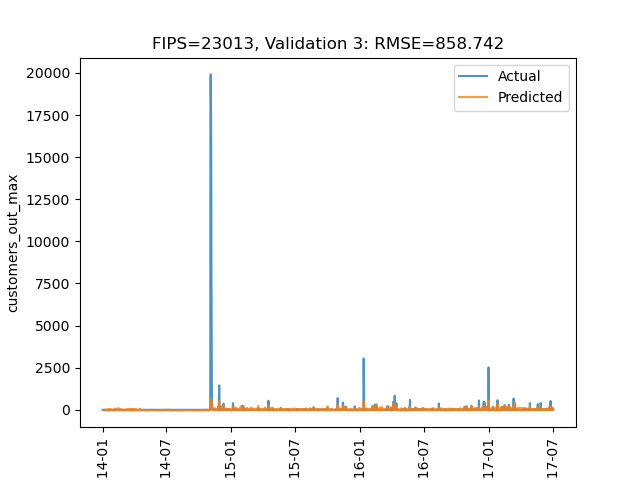

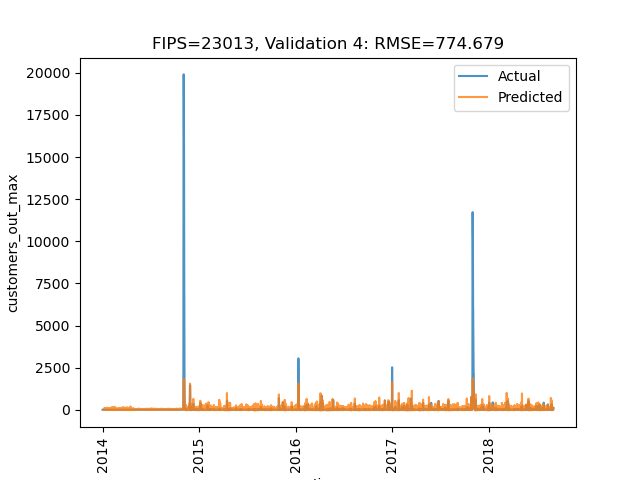

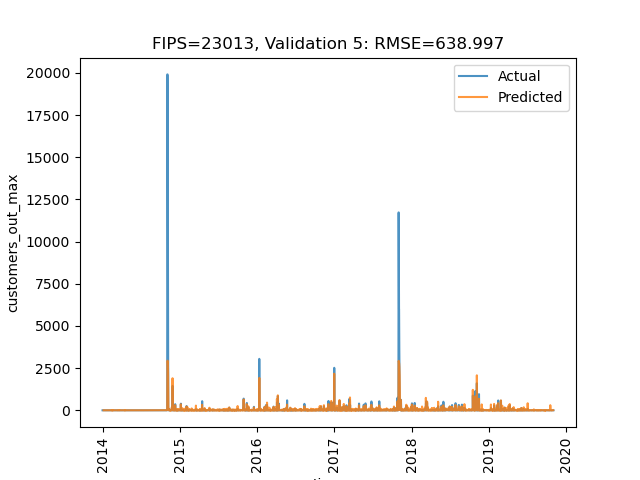

In [213]:
for i , x in enumerate(train_results[fips_test]):
    fig, ax = plt.subplots()
    l2 = ax.plot(x['Actual'], label = 'Actual', alpha = 0.8)
    l1 = ax.plot(x['Predicted'],label = 'Predicted',alpha = 0.8)
    ax.legend()
    ax.set_xlabel('time')
    ax.set_ylabel(target)

    common_indices = x['Actual'].dropna().index.intersection(x['Predicted'].dropna().index)
    rmse = MSEsktime(square_root=True)

    ax.set_title(f'FIPS={int(fips_test)}, Validation {i+1}: RMSE={round(rmse(x['Actual'].loc[common_indices],x['Predicted'].loc[common_indices]),3)}')
    plt.xticks(rotation=90)
    plt.show()

In [32]:
metrics

{23011: [{'loss': 0.008911998011171818,
   'root_mean_squared_error': 0.09440337866544724},
  {'loss': 0.007893143221735954,
   'root_mean_squared_error': 0.08884336054325104},
  {'loss': 0.005343277473002672,
   'root_mean_squared_error': 0.07309772819280624},
  {'loss': 0.0013005008222535253,
   'root_mean_squared_error': 0.03606245666742325},
  {'loss': 0.0036603135522454977,
   'root_mean_squared_error': 0.06050052493810654}],
 23015: [{'loss': 0.0016495927702635527,
   'root_mean_squared_error': 0.040615178644657135},
  {'loss': 0.0014685331843793392,
   'root_mean_squared_error': 0.038321446627378464},
  {'loss': 0.0035683054011315107,
   'root_mean_squared_error': 0.05973529443144798},
  {'loss': 0.0017511884216219187,
   'root_mean_squared_error': 0.04184720292687416},
  {'loss': 0.003922843374311924,
   'root_mean_squared_error': 0.06263260543346405}]}

## Predictions on test data

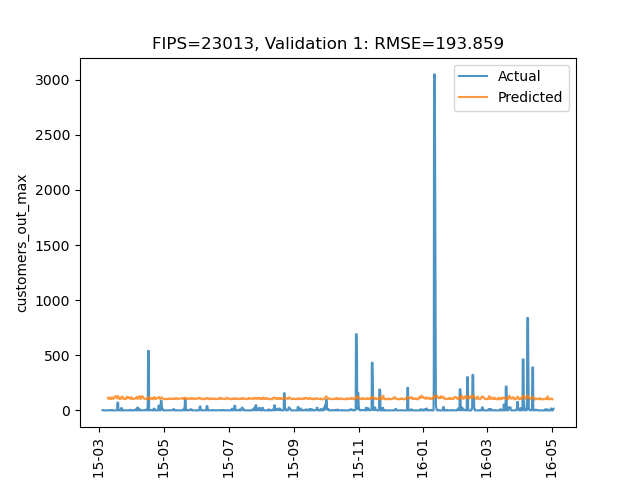

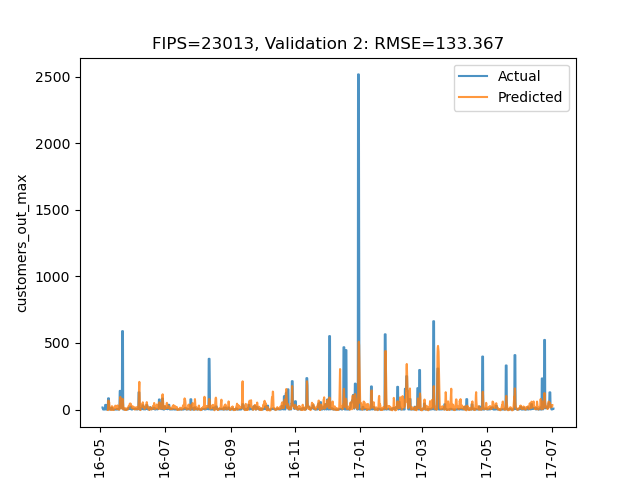

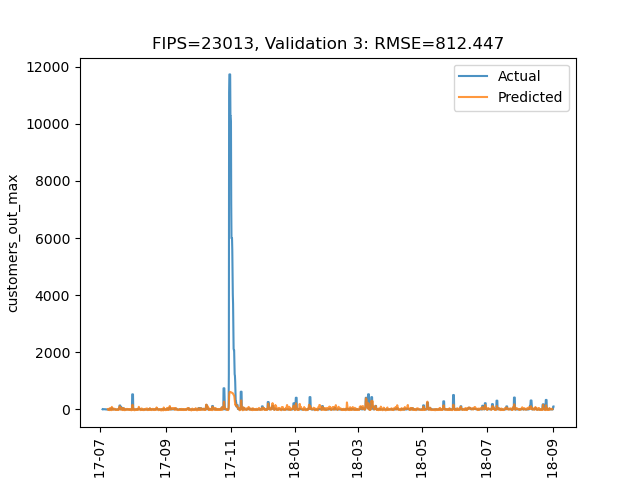

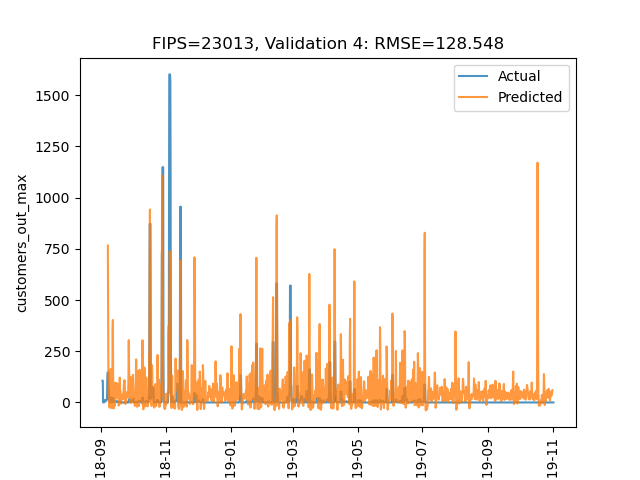

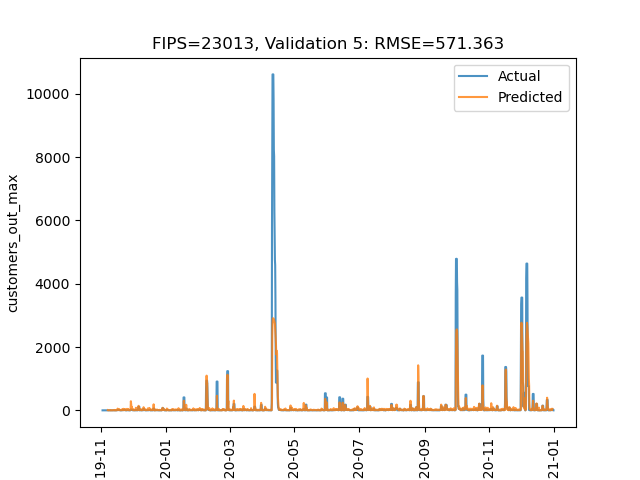

In [214]:
for i , x in enumerate(test_results[fips_test]):
    fig, ax = plt.subplots()
    l2 = ax.plot(x['Actual'], label = 'Actual', alpha = 0.8)
    l1 = ax.plot(x['Predicted'],label = 'Predicted',alpha = 0.8)
    ax.legend()
    ax.set_xlabel('time')
    ax.set_ylabel(target)

    common_indices = x['Actual'].dropna().index.intersection(x['Predicted'].dropna().index)
    rmse = MSEsktime(square_root=True)

    ax.set_title(f'FIPS={int(fips_test)}, Validation {i+1}: RMSE={round(rmse(x['Actual'].loc[common_indices],x['Predicted'].loc[common_indices]),3)}')
    plt.xticks(rotation=90)
    plt.show()

## Forecast on test data

Below we show the 24hr forecast of `customers_out_max` compared to the real data. First we show an interactive plot and then we show the plots for all validations.

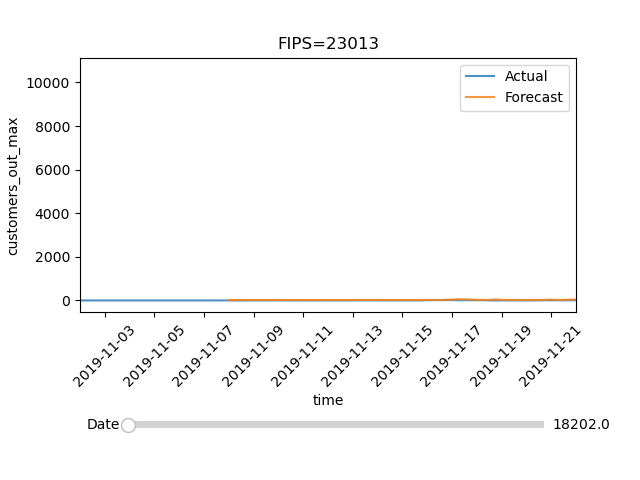

In [233]:
%matplotlib widget

import matplotlib
#import ipywidgets as wd

fig, ax = plt.subplots()
plt.subplots_adjust(bottom=0.35)
ax.set_xlabel('time')
ax.set_ylabel(target)
ax.set_title(f'FIPS={int(fips_test)}')
plt.xticks(rotation=45)

x = test_results[fips_test][-1]

l2 = ax.plot(x['Actual'], label = 'Actual', alpha = 0.8)
l1 = ax.plot(x['Forecast'],label = 'Forecast',alpha = 0.8)
ax.legend()

x_min_index = 0
x_max_index = 20*FORECAST_SIZE

x_min = x.index[x_min_index]
x_max = x.index[x_max_index]

x_dt = x_max - x_min

y_min = plt.axis()[2]
y_max = plt.axis()[3]

plt.axis([x_min, x_max, y_min, y_max])

axpos = plt.axes([0.2, 0.1, 0.65, 0.03])

slider_max = len(x) - x_max_index - 1

spos = Slider(axpos,'Date',matplotlib.dates.date2num(x_min),matplotlib.dates.date2num(x.index[slider_max]))

# play = wd.Play(value = matplotlib.dates.date2num(x_min),
#                min = matplotlib.dates.date2num(x_min),
#                max = matplotlib.dates.date2num(x[slider_max]),
#                step = 1,
#                interval = 500,
#                description = "Press play",
#                disabled = False)

# spos2 = wd.IntSlider(value = matplotlib.dates.date2num(x_min),
#                min = matplotlib.dates.date2num(x_min),
#                max = matplotlib.dates.date2num(x[slider_max]))

# wd.jslink((play,'value'),(spos2,'value'))

# def slider_update(change):
#     pos = change.new
#     x_min_time = matplotlib.dates.num2date(pos)
#     x_max_time = matplotlib.dates.num2date(pos+2)
#     #ax.set_title(f'x_min_time: {type(x_min_time)}')
#     ax.axis([x_min_time,x_max_time,y_min,y_max])

def update(val):
    pos = spos.val
    x_min_time = matplotlib.dates.num2date(pos)
    x_max_time = matplotlib.dates.num2date(pos+2)
    #ax.set_title(f'x_min_time: {type(x_min_time)}')
    ax.axis([x_min_time,x_max_time,y_min,y_max])

spos.on_changed(update)

plt.show()

c:\Users\cacereje\AppData\Local\miniconda3\envs\erdos_spring_2025\Lib\site-packages\sktime\performance_metrics\forecasting\_classes.py:673: UserWarning: y_pred and y_true do not have the same column index. This may indicate incorrect objects passed to the metric. Indices of y_true will be used for y_pred.
  warn(


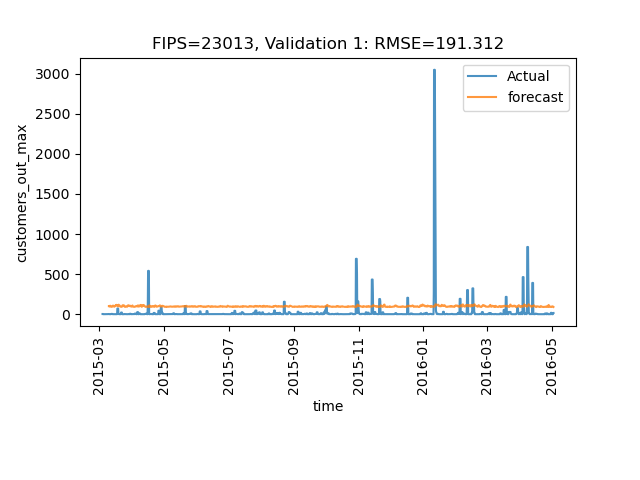

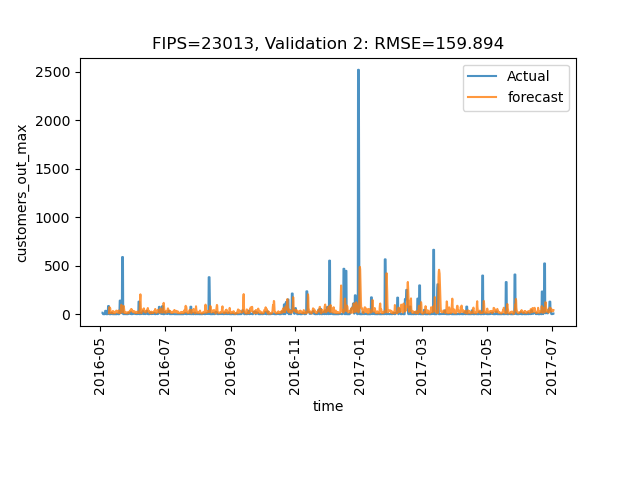

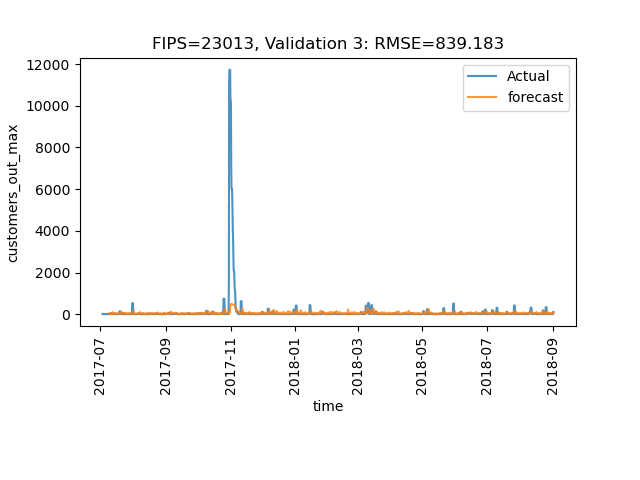

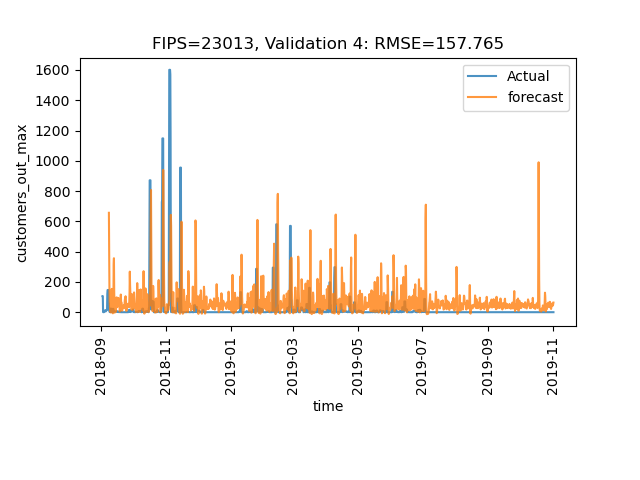

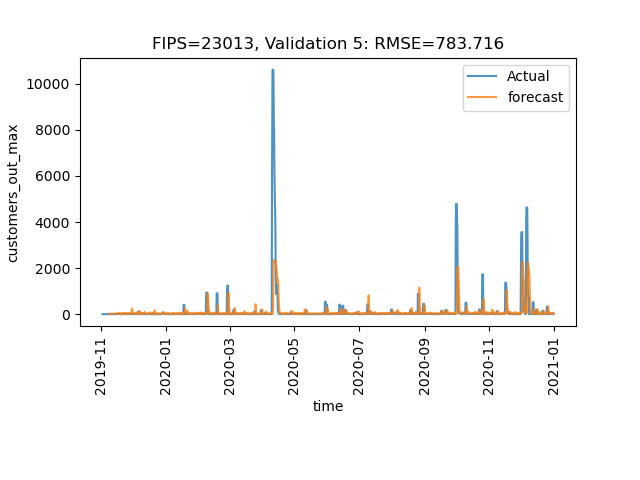

In [234]:
%matplotlib widget

for i , x in enumerate(test_results[fips_test]):
    fig, ax = plt.subplots()
    fig.subplots_adjust(bottom=0.32)
    l2 = ax.plot(x['Actual'], label = 'Actual', alpha = 0.8)
    l1 = ax.plot(x['Forecast'],label = 'forecast',alpha = 0.8)
    ax.legend()
    ax.set_xlabel('time')
    ax.set_ylabel(target)

    common_indices = x['Actual'].dropna().index.intersection(x['Forecast'].dropna().index)
    rmse = MSEsktime(square_root=True)

    ax.set_title(f'FIPS={int(fips_test)}, Validation {i+1}: RMSE={round(rmse(x['Actual'].loc[common_indices],x['Forecast'].loc[common_indices]),3)}')

    plt.xticks(rotation=90)
    # ax_t = fig.add_axes([0.25, 0.1, 0.65, 0.03])

    # t_index_min = time_indices[fips_test][i][1][WINDOW_SIZE]
    # t_index_max = time_indices[fips_test][i][1][-FORECAST_SIZE]
    # t_index_range = time_indices[fips_test][i][1][WINDOW_SIZE:-FORECAST_SIZE]

    # t_slider = Slider(ax_t,"Date",t_index_min,t_index_max, valinit = t_index_max, valstep= t_index_range)
    
    # def Update(val):
    #     t = t_slider.val
    #     ax.set_xlim(df_county['datetime'].iloc[t:t+FORECAST_SIZE])
        
    # t_slider.on_changed(Update)    

    plt.show()

## RMSEs for all counties

In [218]:
rmses_state = {}

for fips in fips_list:
    x = test_results[fips][-1]
    common_indices = x['Actual'].dropna().index.intersection(x['Predicted'].dropna().index)
    rmse = MSEsktime(square_root=True)
    
    rmses_state[str(fips)] = round(rmse(x['Actual'].loc[common_indices],x['Predicted'].loc[common_indices]),3)

df_rmses = pd.DataFrame.from_dict(rmses_state,orient='index',columns=['RMSE'])



c:\Users\cacereje\AppData\Local\miniconda3\envs\erdos_spring_2025\Lib\site-packages\sktime\performance_metrics\forecasting\_classes.py:673: UserWarning: y_pred and y_true do not have the same column index. This may indicate incorrect objects passed to the metric. Indices of y_true will be used for y_pred.
  warn(


In [229]:
import geopandas as gpd
loc = '../../data/NWS_US_Counties_Shapefiles/c_05mr24.shp'
counties = gpd.read_file(loc)

counties = counties[counties['STATE'] == state]
counties.set_index('FIPS', inplace=True)


Below we have the RMSE for each county in the state.

In [230]:
counties = pd.concat([counties,df_rmses],axis=1)
counties

,STATE,CWA,COUNTYNAME,TIME_ZONE,FE_AREA,LON,LAT,geometry,RMSE
23029,ME,CAR,Washington,E,se,-67.6361,45.0363,"MULTIPOLYGON (((-67.93539 44.40382, -67.93643 ...",360.027
23001,ME,GYX,Androscoggin,E,sw,-70.2045,44.1654,"POLYGON ((-70.1188 44.45041, -70.1162 44.44031...",1941.507
23013,ME,GYX,Knox,E,sc,-69.1730,44.1500,"MULTIPOLYGON (((-69.19708 44.31189, -69.13098 ...",571.363
23023,ME,GYX,Sagadahoc,E,sc,-69.8613,43.9705,"MULTIPOLYGON (((-69.8327 43.69529, -69.83279 4...",658.777
23015,ME,GYX,Lincoln,E,sc,-69.5431,44.0752,"MULTIPOLYGON (((-69.58221 43.75232, -69.58319 ...",927.590
23021,ME,CAR,Piscataquis,E,nc,-69.2835,45.8380,"POLYGON ((-69.6256 46.57391, -69.61169 46.5736...",838.971
23025,ME,GYXCAR,Somerset,E,wc,-69.9582,45.5138,"POLYGON ((-69.72089 46.57381, -69.7203 46.5541...",1817.939
23003,ME,CAR,Aroostook,E,nn,-68.5988,46.6588,"POLYGON ((-69.20556 47.45217, -69.20519 47.451...",663.268
23017,ME,GYX,Oxford,E,ww,-70.7555,44.4990,"POLYGON ((-70.98531 45.33241, -70.98497 45.331...",1454.758
23019,ME,CAR,Penobscot,E,ec,-68.6494,45.4006,"POLYGON ((-68.756 46.39531, -68.7485 46.39551,...",4034.469


Here's a summary of the RMSE's:

In [231]:
counties['RMSE'].describe()

count      16.000000
mean     1596.147000
std      1076.495353
min       360.027000
25%       795.045250
50%      1372.328500
75%      1971.601750
max      4034.469000
Name: RMSE, dtype: float64

In [226]:
import geopandas as gpd
from matplotlib.colors import ListedColormap, Normalize

def plot_rmse_on_map_state(data,feature,state='ME'):
    
    loc = '../../data/NWS_US_Counties_Shapefiles/c_05mr24.shp'
    counties = gpd.read_file(loc)

    counties = counties[counties['STATE'] == state]
    counties.set_index('FIPS', inplace=True)
    
    counties = pd.concat([counties,data],axis=1)

    # Create a custom colormap
    viridis_cmap = plt.cm.viridis  # Base colormap
    colors = viridis_cmap(np.linspace(0, 1, 256))  # Extract colors from viridis
    colors[0] = np.array([1, 1, 1, 1])  # Set the first color (for zero values) to white
    custom_cmap = ListedColormap(colors)
    
    # Plot the map
    fig, ax = plt.subplots(1, 1, figsize=(10, 6))
    county_plot = counties.plot(column=feature,  # Data to visualize
                                cmap=custom_cmap,  # Colormap
                                linewidth=0.8,
                                ax=ax,
                                edgecolor='black',
                                legend=False,  # Disable automatic colorbar
                                norm=Normalize(vmin=0, vmax=counties[feature].max())  # Normalize scale
                               )
    
    # Add colorbar and set its title
    sm = plt.cm.ScalarMappable(cmap=custom_cmap, norm=Normalize(vmin=0, vmax=counties[feature].max()))
    sm._A = []  # Dummy array for the ScalarMappable
    cbar = fig.colorbar(sm, ax=ax)
    # cbar.set_label('Number of Customers Out', fontsize=12, labelpad=10)
    cbar.ax.xaxis.set_label_position('top')
    cbar.ax.xaxis.set_ticks_position('top')
    cbar.ax.set_xlabel('RMSE', fontsize=14)
    
    # Remove the vertical label
    cbar.ax.set_ylabel('')
    
    # Customize the plot
    title = f"RMSE for each county in {state}"
    ax.set_title(title, fontsize=14)
    ax.axis('off')  # Turn off the axis
    plt.show()

    return


and here a map to visualize where the RMSE is the highest. This should be compared to the map that shows the outages for the time period.

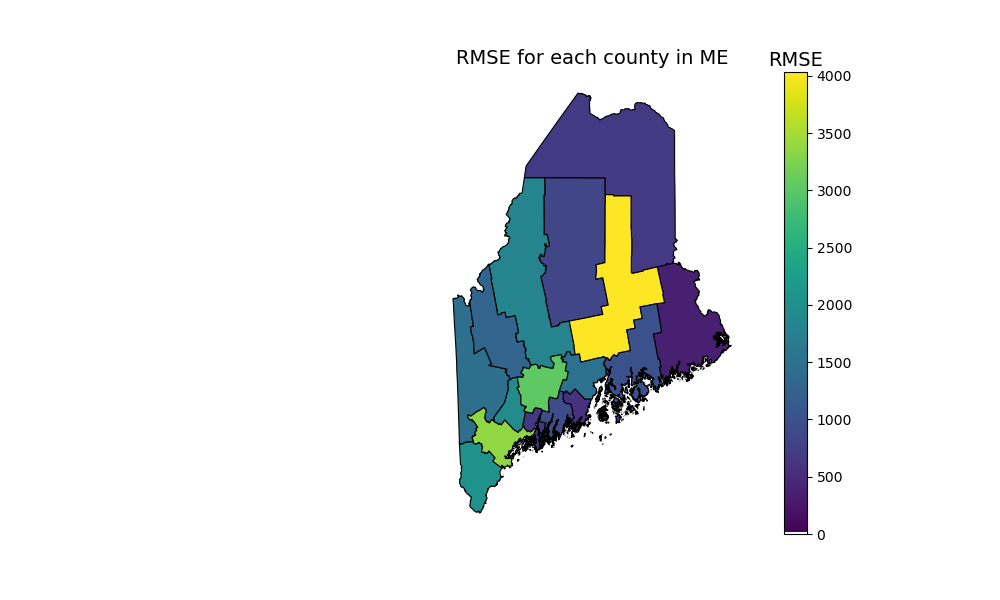

In [227]:
plot_rmse_on_map_state(df_rmses,feature='RMSE')